In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("libraries loaded")

Matplotlib is building the font cache; this may take a moment.


libraries loaded


21 Apr
I pulled data from yfinance for the stocks od Apple, nicrosoft, and the S&P 500 ETF. I computed the raw prices, log returns, volatility, and the 30 day rolling volatility. Then, using matplotlib the Apple info was plotted.

In [19]:
tickers = ["AAPL", "MSFT", "SPY"]

data = {}
for ticker in tickers:
    try:
        d = yf.download(ticker, start="2019-01-01", end="2024-01-01", progress=False)
        # Handle multi-level columns if present
        if isinstance(d.columns, pd.MultiIndex):
            d.columns = d.columns.droplevel(1)
        data[ticker] = d["Close"]
        print(f"{ticker}: {len(d)} rows downloaded")
    except Exception as e:
        print(f"{ticker}: failed — {e}")

# Combine into one clean DataFrame
prices = pd.concat(data, axis=1)
prices.columns = tickers
print(f"\nShape: {prices.shape}")
print(prices.head())

AAPL: 1258 rows downloaded
MSFT: 1258 rows downloaded
SPY: 1258 rows downloaded

Shape: (1258, 3)
                 AAPL       MSFT         SPY
Date                                        
2019-01-02  37.503727  94.397171  224.382538
2019-01-03  33.768078  90.924454  219.028137
2019-01-04  35.209614  95.153290  226.364655
2019-01-07  35.131245  95.274643  228.149460
2019-01-08  35.800961  95.965454  230.292999


In [20]:
print(prices.head(10))
print(f"\nShape: {prices.shape}")
print(f"\nMissing values:\n{prices.isnull().sum()}")

                 AAPL       MSFT         SPY
Date                                        
2019-01-02  37.503727  94.397171  224.382538
2019-01-03  33.768078  90.924454  219.028137
2019-01-04  35.209614  95.153290  226.364655
2019-01-07  35.131245  95.274643  228.149460
2019-01-08  35.800961  95.965454  230.292999
2019-01-09  36.408924  97.337738  231.369247
2019-01-10  36.525288  96.712280  232.185410
2019-01-11  36.166687  95.965454  232.275177
2019-01-14  35.622841  95.265335  230.858063
2019-01-15  36.351921  98.028542  233.503815

Shape: (1258, 3)

Missing values:
AAPL    0
MSFT    0
SPY     0
dtype: int64


In [22]:
simple_returns = prices.pct_change()
log_returns = np.log(prices / prices.shift(1))

simple_returns.head(5)

,AAPL,MSFT,SPY
Date,,,
2019-01-02,NaN,NaN,NaN
2019-01-03,-0.099607,-0.036788,-0.023863
2019-01-04,0.042689,0.046509,0.033496
2019-01-07,-0.002226,0.001275,0.007885
2019-01-08,0.019063,0.007251,0.009395


In [32]:
log_returns.head(5)

,AAPL,MSFT,SPY
Date,,,
2019-01-02,NaN,NaN,NaN
2019-01-03,-0.104924,-0.037482,-0.024152
2019-01-04,0.041803,0.045460,0.032947
2019-01-07,-0.002228,0.001275,0.007854
2019-01-08,0.018884,0.007225,0.009351


In [29]:
#30-day rolling window
rolling_vol = (log_returns.rolling(window=30).std())*np.sqrt(252)
#first 30 are empty

In [ ]:
import os
print(os.getcwd()) #to fix bug in relative path

/Users/maridel/Documents/Projects/quant-research/notebooks


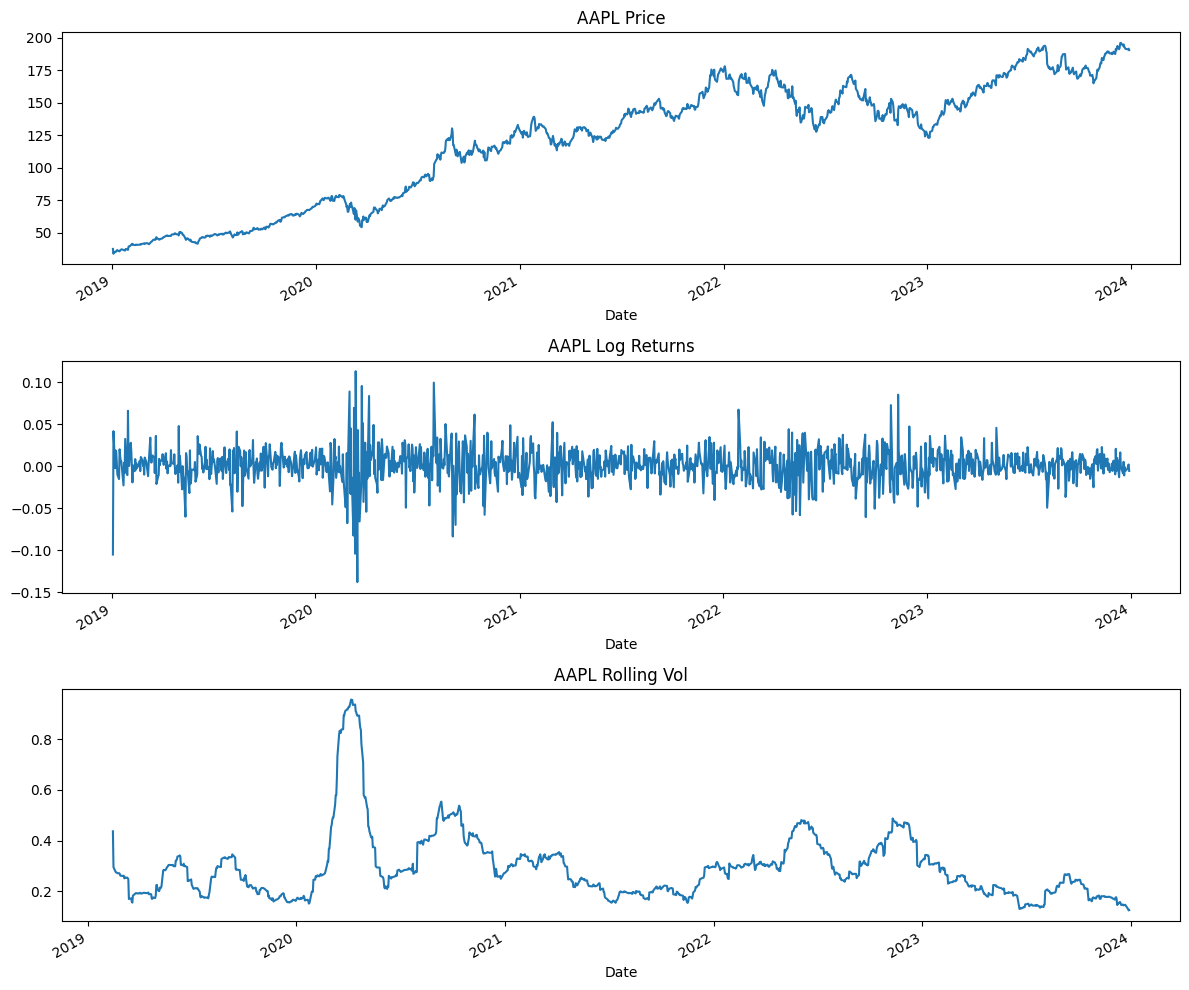

In [35]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10))

prices["AAPL"].plot(ax=axes[0], title="AAPL Price")
log_returns["AAPL"].plot(ax=axes[1], title="AAPL Log Returns")
rolling_vol["AAPL"].plot(ax=axes[2], title="AAPL Rolling Vol")


plt.tight_layout()
plt.savefig("aapl_exploration.png", dpi=150)
plt.show()

Here, the 2020 COVID market crash is visible in all charts- a drop in price in 2020, a wider reange in the log returns, and a spike in the rolling volatility.